In [1]:
import pandas as pd
import requests
import json
from scipy.stats import norm
import matplotlib.pyplot as plt


In [2]:
rq = requests.get("https://api.csapi.de/players/stats/?limit=17713")

In [3]:
data = rq.text

parsed = json.loads(data)

df = pd.DataFrame().from_dict(parsed)
print(df)

          id         name   k   d  swing   adr  kast  rating
0      20879      maxster  48  38   2.33  83.8  76.8    1.30
1      21159     bobeksde  41  42   4.25  80.4  76.8    1.28
2      21012         ro1f  28  39  -1.75  67.3  69.6    0.94
3       3849           jw  32  40  -5.04  56.3  57.1    0.72
4      22914          dex  27  45  -4.07  50.4  62.5    0.69
...      ...          ...  ..  ..    ...   ...   ...     ...
17708  21988       opdust  23  32  -3.11  55.6  69.2    0.80
17709  18240        smash  40  31   2.04  77.6  80.8    1.36
17710  20110        marix  34  38  -0.67  71.2  61.5    0.99
17711   2131       bondik  29  33  -0.93  70.7  67.3    0.97
17712  19614  s4ltovsk1yy  30  34  -1.29  56.1  57.7    0.87

[17713 rows x 8 columns]


(17.210055981673293, 1691474.675934723, -0.08733979753201454, 112723.91479588085)
0.78581111108375 1.333384443196838
0.7825721240386472 1.3360311616837037
1.0593016428611755
0.2767295188225283


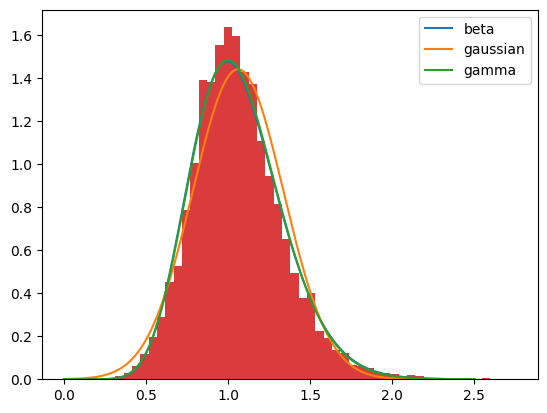

In [7]:
import math
import numpy as np
import scipy.stats as stats

ratings = df['rating']

mu = ratings.mean()
variance = ratings.std()
sigma = math.sqrt(variance)
x = np.linspace(0, 2.5, 500)
params = stats.beta.fit(ratings)

params_norm = stats.norm.fit(ratings)
params_gamma = stats.gamma.fit(ratings)
print(params)
plt.plot(x, stats.beta.pdf(x,*params), label='beta')
plt.plot(x, stats.norm.pdf(x,*params_norm), label='gaussian')
plt.plot(x, stats.gamma.pdf(x,*params_gamma), label='gamma')

plt.legend()


# print(f"EV: {scale * (a/(a+b)) + l}")

lower_1sigma = stats.beta.ppf(0.15865, *params)
upper_1sigma = stats.beta.ppf(0.84135, *params)

print(lower_1sigma, upper_1sigma)
print(ratings.mean() - ratings.std(), ratings.mean() + ratings.std())

ratings =df['rating']
plt.hist(ratings, bins=50, density=True, alpha=0.9)
print(ratings.mean())
print(ratings.std())

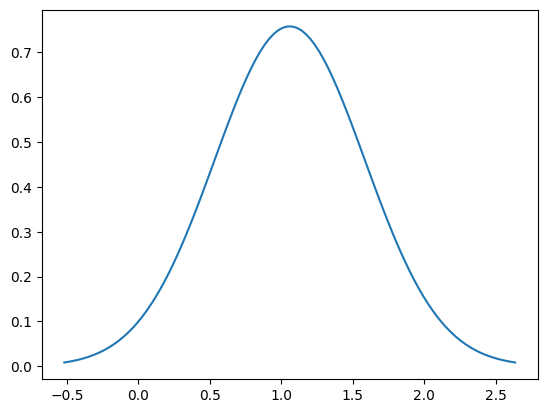

12019    0.21
3830     0.22
6993     0.23
594      0.24
16381    0.26
         ... 
1485     2.56
11490    2.57
4376     2.58
11690    2.74
585      2.75
Name: rating, Length: 17714, dtype: float64


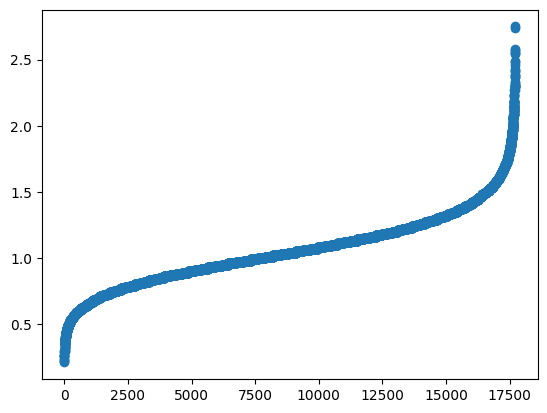

In [87]:
print(ratings.sort_values())
plt.scatter(range(len(ratings)),list(ratings.sort_values()))

2.75


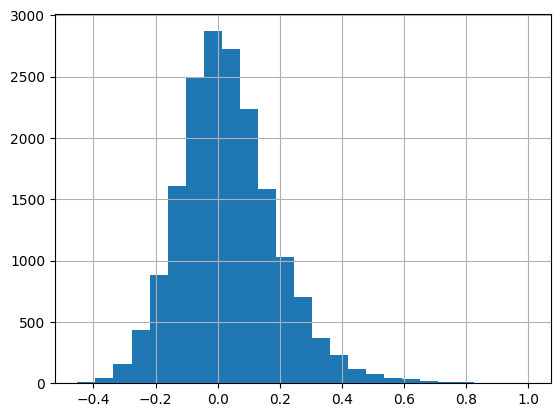

In [72]:
print(ratings.max())
rating_normalized = (ratings-1)/(ratings.max()-1)

ax2 = rating_normalized.hist(bins=25)

[-0.45142857142857146, -0.44571428571428573, -0.44, -0.4342857142857143, -0.4228571428571429, -0.4228571428571429, -0.4228571428571429, -0.41714285714285715, -0.4057142857142857, -0.39999999999999997, -0.39999999999999997, -0.39999999999999997, -0.39428571428571424, -0.3885714285714285, -0.38285714285714284, -0.38285714285714284, -0.38285714285714284, -0.3771428571428571, -0.37142857142857144, -0.37142857142857144, -0.37142857142857144, -0.37142857142857144, -0.37142857142857144, -0.37142857142857144, -0.3657142857142857, -0.3657142857142857, -0.3657142857142857, -0.3657142857142857, -0.36, -0.36, -0.36, -0.35428571428571426, -0.35428571428571426, -0.35428571428571426, -0.35428571428571426, -0.35428571428571426, -0.35428571428571426, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.3485714285714286, -0.34285714285714286, -0.34285714285714286, -0

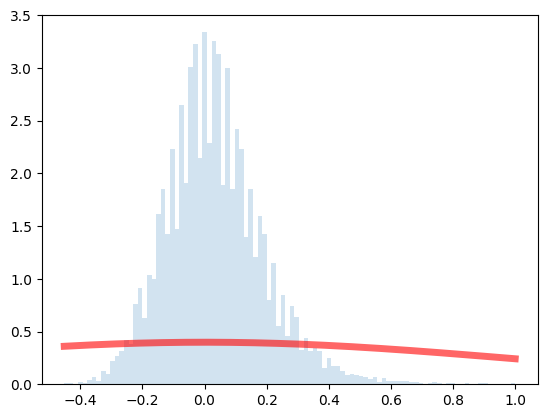

In [73]:
lb, ub = norm.support()
mean, var, skew, kurt = norm.stats(moments='mvsk')
x = sorted(list(rating_normalized))
print(x)
plt.plot(x, norm.pdf(x),
       'r-', lw=5, alpha=0.6, label='norm pdf')
plt.hist(rating_normalized, density=True, bins='auto', histtype='stepfilled', alpha=0.2)

# ax.set_xlim([x[0], x[-1]])

# ax.legend(loc='best', frameon=False)

plt.show()


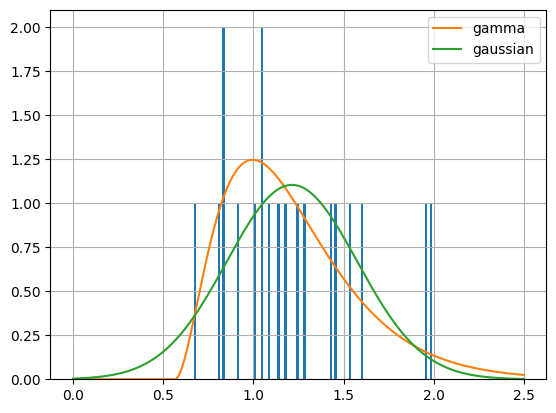

w0nderful 19
0.67
lower: 0.86 upper: 1.57
Points range(1sigma): -7.03 - 28.51
gaussian:
lower: 0.85 upper: 1.58
Points range(1sigma): -7.35 - 28.77
Points mean: 10.71 beta: 1.21, gaussian: 1.21



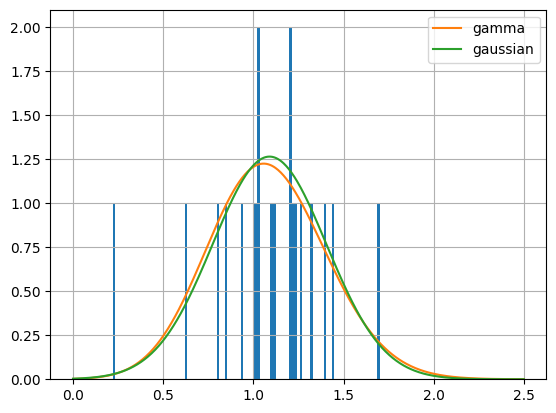

makazze 19
0.22
lower: 0.76 upper: 1.41
Points range(1sigma): -12.22 - 20.38
gaussian:
lower: 0.77 upper: 1.40
Points range(1sigma): -11.29 - 20.24
Points mean: 4.47 beta: 1.08, gaussian: 1.09



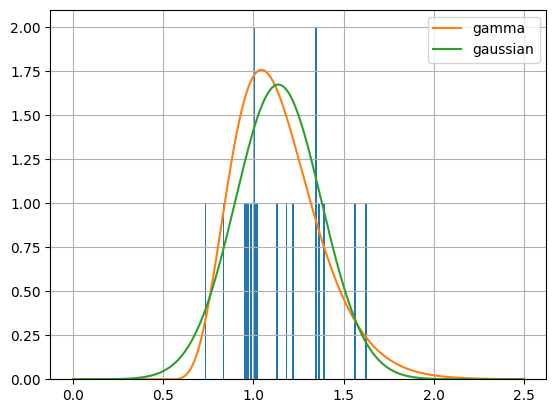

im 19
0.73
lower: 0.90 upper: 1.37
Points range(1sigma): -4.89 - 18.75
gaussian:
lower: 0.90 upper: 1.38
Points range(1sigma): -4.99 - 18.83
Points mean: 6.92 beta: 1.14, gaussian: 1.14



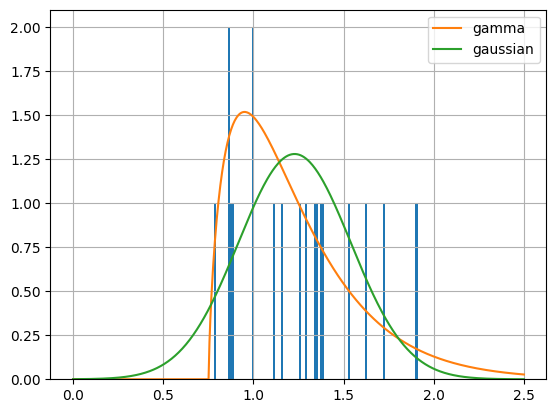

ropz 19
0.78
lower: 0.90 upper: 1.56
Points range(1sigma): -4.92 - 27.89
gaussian:
lower: 0.92 upper: 1.54
Points range(1sigma): -4.16 - 27.01
Points mean: 11.42 beta: 1.23, gaussian: 1.23



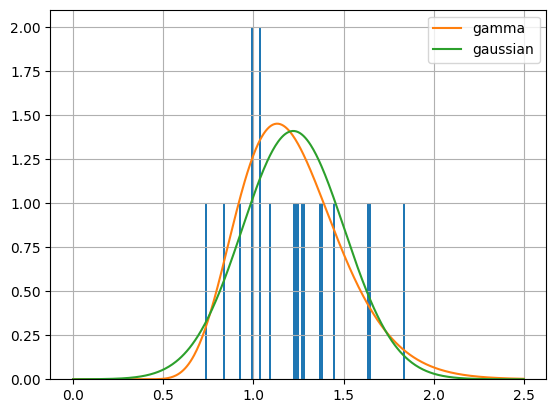

flamez 19
0.73
lower: 0.94 upper: 1.50
Points range(1sigma): -3.04 - 25.15
gaussian:
lower: 0.94 upper: 1.50
Points range(1sigma): -3.09 - 25.19
Points mean: 11.05 beta: 1.22, gaussian: 1.22



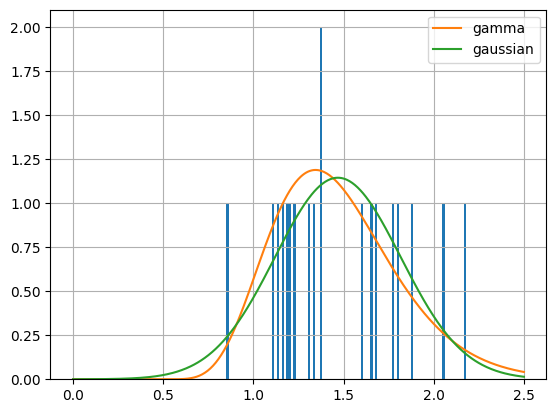

zywoo 19
0.85
lower: 1.12 upper: 1.82
Points range(1sigma): 6.09 - 40.76
gaussian:
lower: 1.12 upper: 1.82
Points range(1sigma): 6.00 - 40.84
Points mean: 23.42 beta: 1.47, gaussian: 1.47



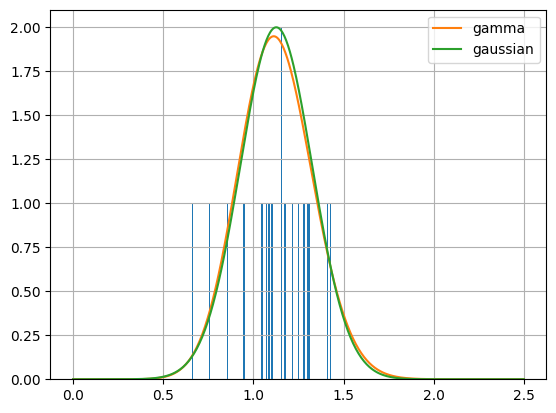

mezii 19
0.66
lower: 0.92 upper: 1.33
Points range(1sigma): -4.00 - 16.49
gaussian:
lower: 0.93 upper: 1.33
Points range(1sigma): -3.63 - 16.32
Points mean: 6.34 beta: 1.12, gaussian: 1.13



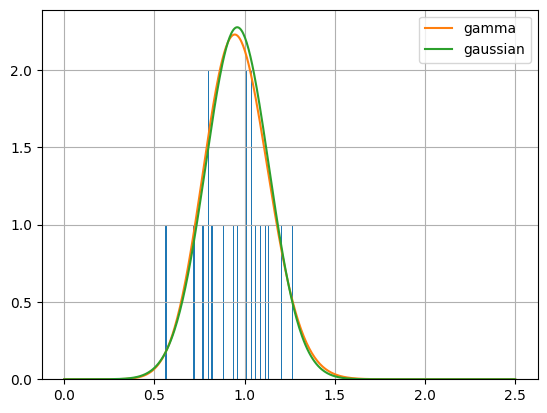

apex 19
0.56
lower: 0.78 upper: 1.14
Points range(1sigma): -11.09 - 6.83
gaussian:
lower: 0.78 upper: 1.13
Points range(1sigma): -10.82 - 6.71
Points mean: -2.05 beta: 0.96, gaussian: 0.96



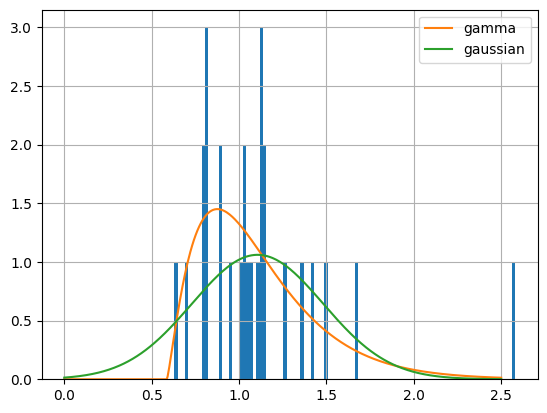

nota 27
0.63
lower: 0.79 upper: 1.43
Points range(1sigma): -10.66 - 21.33
gaussian:
lower: 0.73 upper: 1.48
Points range(1sigma): -13.51 - 24.10
Points mean: 5.30 beta: 1.11, gaussian: 1.11



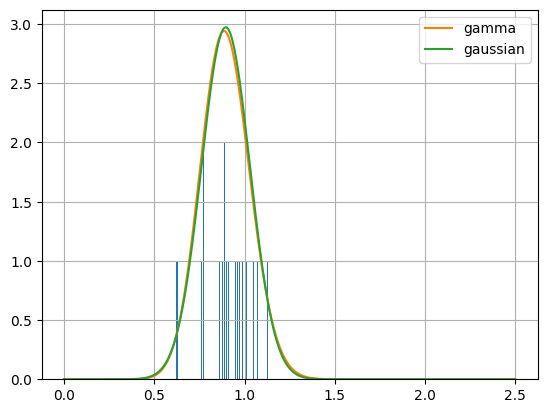

aleksib 19
0.62
lower: 0.76 upper: 1.03
Points range(1sigma): -12.09 - 1.48
gaussian:
lower: 0.76 upper: 1.03
Points range(1sigma): -11.95 - 1.47
Points mean: -5.24 beta: 0.89, gaussian: 0.90



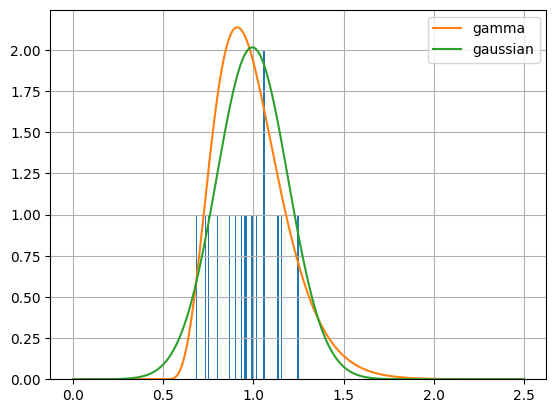

kyxsan 18
0.68
lower: 0.80 upper: 1.19
Points range(1sigma): -10.09 - 9.49
gaussian:
lower: 0.80 upper: 1.19
Points range(1sigma): -10.20 - 9.59
Points mean: -0.31 beta: 0.99, gaussian: 0.99



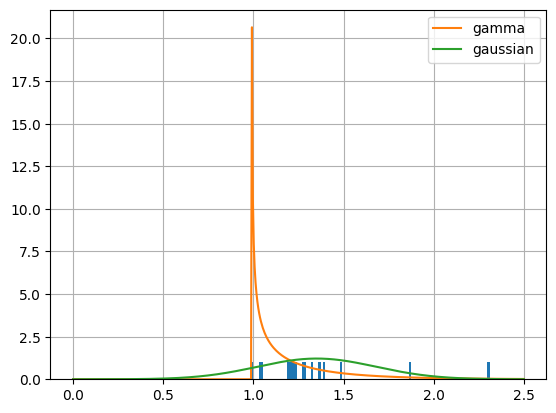

kyousuke 15
0.99
lower: 1.00 upper: 1.39
Points range(1sigma): -0.14 - 19.47
gaussian:
lower: 1.02 upper: 1.68
Points range(1sigma): 1.17 - 33.96
Points mean: 17.57 beta: 1.19, gaussian: 1.35



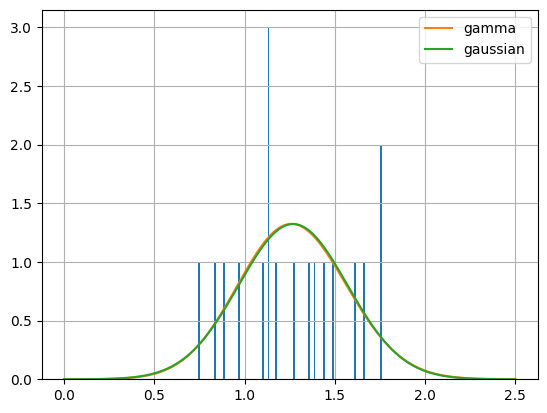

m0nesy 18
0.74
lower: 0.97 upper: 1.57
Points range(1sigma): -1.63 - 28.50
gaussian:
lower: 0.97 upper: 1.57
Points range(1sigma): -1.63 - 28.52
Points mean: 13.44 beta: 1.27, gaussian: 1.27



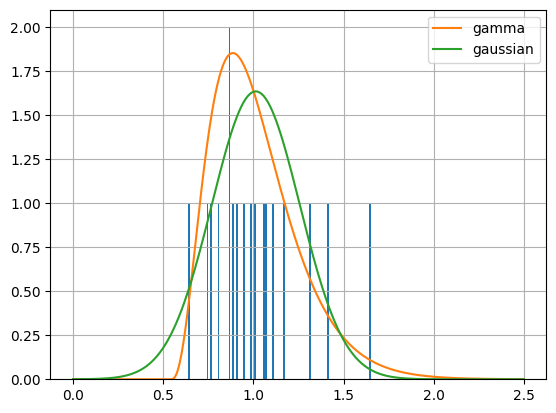

teses 18
0.64
lower: 0.78 upper: 1.25
Points range(1sigma): -10.99 - 12.35
gaussian:
lower: 0.77 upper: 1.26
Points range(1sigma): -11.53 - 12.86
Points mean: 0.67 beta: 1.01, gaussian: 1.01



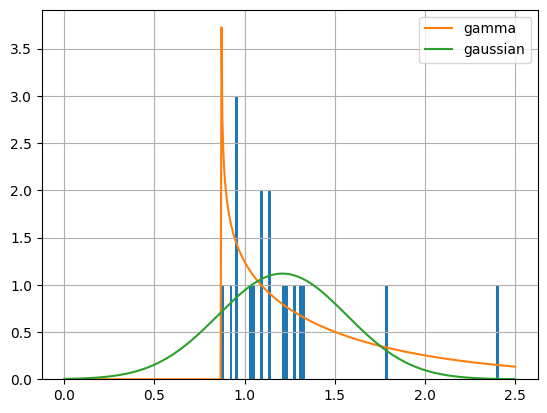

niko 18
0.87
lower: 0.95 upper: 2.20
Points range(1sigma): -2.48 - 60.07
gaussian:
lower: 0.85 upper: 1.57
Points range(1sigma): -7.36 - 28.31
Points mean: 10.47 beta: 1.57, gaussian: 1.21



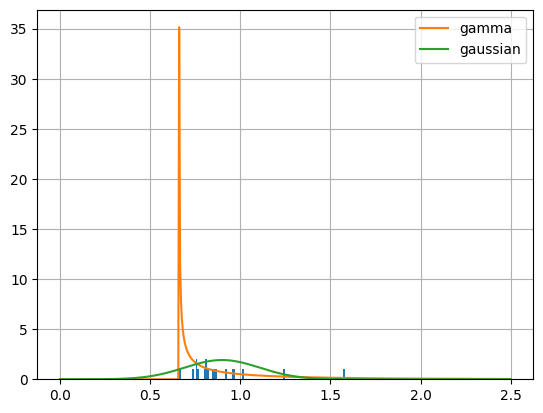

maj3r 18
0.66
lower: 0.66 upper: 1.21
Points range(1sigma): -16.93 - 10.48
gaussian:
lower: 0.69 upper: 1.11
Points range(1sigma): -15.41 - 5.35
Points mean: -5.03 beta: 0.94, gaussian: 0.90



In [251]:
import warnings
warnings.filterwarnings("ignore")

players = [
    'w0nderful',
    'makazze',
    'im',
    'ropz',
    'flamez',
    'zywoo',
    'mezii',
    'apex',
    'nota',
    'aleksib',
    'kyxsan',
    'kyousuke',
    'm0nesy',
    'teses',
    'niko',
    'maj3r'
    ]


for p in players:
    df_p = df[df['name'] == p]
    p_ratings = (df_p['rating'])
    p_ratings.hist(bins=100)
    # plt.show()

    params = stats.gamma.fit(p_ratings)
    params_norm = stats.norm.fit(p_ratings)

    lower_1sigma = stats.gamma.ppf(0.15865, *params)
    upper_1sigma = stats.gamma.ppf(0.84135, *params)

    lower_1sigma_norm = stats.norm.ppf(0.15865, *params_norm)
    upper_1sigma_norm = stats.norm.ppf(0.84135, *params_norm)
    mean = stats.gamma.mean(*params)

    x = np.linspace(0, 2.5, 500)

    plt.plot(x, stats.gamma.pdf(x,*params), label='gamma')
    plt.plot(x, stats.norm.pdf(x,*params_norm), label='gaussian')
    plt.legend()
    plt.show()

    print(p, len(p_ratings))
    print(p_ratings.min())
    print(f"lower: {lower_1sigma:.2f}", f"upper: {upper_1sigma:.2f}")
    print(f"Points range(1sigma): {(lower_1sigma-1)*50:.2f} - {(upper_1sigma-1)*50:.2f}")
    print('gaussian:')
    print(f"lower: {lower_1sigma_norm:.2f}", f"upper: {upper_1sigma_norm:.2f}")
    print(f"Points range(1sigma): {(lower_1sigma_norm-1)*50:.2f} - {(upper_1sigma_norm-1)*50:.2f}")
    print(f"Points mean: {(p_ratings.mean()-1)*50:.2f} beta: {mean:.2f}, gaussian: {stats.norm.mean(*params_norm):.2f}")
    print()

    # print(f"mean: {mean:.2f}", f"{p_ratings.mean():.2f}", f"Points mean: {(p_ratings.mean()-1)*50:.2f}")